<a href="https://colab.research.google.com/github/Raymondycp/Analytic_SupermarketSales_SQL_RFM/blob/main/%5BAnalytic%5DSupermarketSales_SQL_RFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install duckdb

In [ ]:
import pandas as pd
df=pd.read_csv('/content/Supermart.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         9994 non-null   object        
 1   customer_name    9994 non-null   object        
 2   category         9994 non-null   object        
 3   subcategory      9994 non-null   object        
 4   city             9994 non-null   object        
 5   order_date       9994 non-null   datetime64[ns]
 6   region           9994 non-null   object        
 7   sales_amount     9994 non-null   int64         
 8   discount_amount  9994 non-null   float64       
 9   profit_amount    9994 non-null   float64       
 10  state            9994 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 859.0+ KB


In [ ]:
print(df[['order_date']].max())
df.customer_name.unique()

order_date   2018-12-30
dtype: datetime64[ns]


array(['Harish', 'Sudha', 'Hussain', 'Jackson', 'Ridhesh', 'Adavan',
       'Jonas', 'Hafiz', 'Krithika', 'Ganesh', 'Yadav', 'Sharon', 'Peer',
       'Sundar', 'Ramesh', 'Alan', 'Arutra', 'Haseena', 'Verma', 'Muneer',
       'Veronica', 'Shah', 'Mathew', 'Akash', 'Anu', 'Sabeela', 'James',
       'Willams', 'Malik', 'Amrish', 'Vince', 'Suresh', 'Esther', 'Yusuf',
       'Komal', 'Veena', 'Shree', 'Roshan', 'Sudeep', 'Vinne', 'Vidya',
       'Arvind', 'Kumar', 'Amy', 'Ravi', 'Sheeba', 'Ram', 'Rumaiza',
       'Aditi', 'Surya'], dtype=object)

In [ ]:
column_mapping = {
    'Order ID': 'order_id',
    'Customer Name': 'customer_name',
    'Category': 'category',
    'Sub Category': 'subcategory',  # Removed space, made one word
    'City': 'city',
    'Order Date': 'order_date',
    'Region': 'region',
    'Sales': 'sales_amount',  # More specific
    'Discount': 'discount_amount',  # More specific
    'Profit': 'profit_amount',  # More specific
    'State': 'state'
}

# Apply the renaming
df = df.rename(columns=column_mapping)

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed')

In [ ]:
df['customer_name'].value_counts()

,count
customer_name,
Amrish,227
Krithika,224
Verma,218
Arutra,218
Vidya,215
Shah,215
Suresh,212
Surya,209
Hussain,208


# Business Questions

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global style
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
palette = 'viridis'

## 1. Which are the top 5 most profitable product categories?

In [ ]:
import duckdb
duckdb.sql("""
    SELECT category, ROUND(SUM(profit_amount), 2) AS total_profit
    FROM df GROUP BY category
    ORDER BY total_profit DESC LIMIT 5
    """)


┌───────────────────┬──────────────┐
│     category      │ total_profit │
│      varchar      │    double    │
├───────────────────┼──────────────┤
│ Snacks            │    568178.85 │
│ Eggs, Meat & Fish │    567357.22 │
│ Fruits & Veggies  │    530400.38 │
│ Food Grains       │    529162.64 │
│ Bakery            │    528521.06 │
└───────────────────┴──────────────┘

<ipython-input-72-a69e97f28792>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



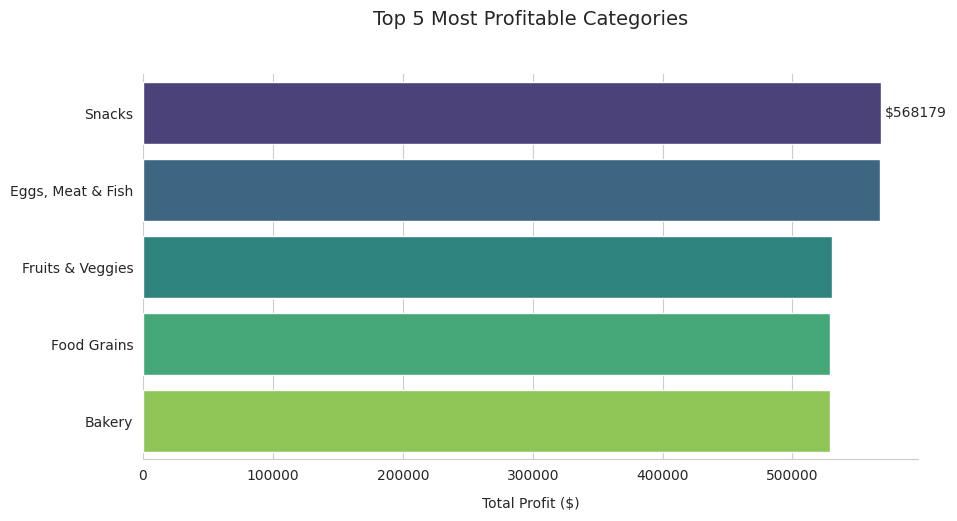

In [ ]:
q1 = duckdb.sql("""
    SELECT category, ROUND(SUM(profit_amount), 2) AS total_profit
    FROM df GROUP BY category
    ORDER BY total_profit DESC LIMIT 5
""").df()

plt.figure(figsize=(10,5))
ax = sns.barplot(y='category', x='total_profit', data=q1, palette=palette)
plt.title('Top 5 Most Profitable Categories\n', fontsize=14, pad=20)
plt.xlabel('Total Profit ($)', labelpad=10)
plt.ylabel('')
ax.bar_label(ax.containers[0], fmt='$%.0f', padding=3)
sns.despine(left=True)
plt.show()

## 2. How does sales performance compare across different regions?

In [ ]:
import duckdb
duckdb.sql("""
    SELECT
    region,
    ROUND(SUM(sales_amount), 2) AS total_sales,
    ROUND(SUM(profit_amount), 2) AS total_profit,
    ROUND(SUM(profit_amount)/SUM(sales_amount)*100, 2) AS profit_margin_percentage
    FROM df
    GROUP BY region
    ORDER BY total_sales DESC;
    """)

┌─────────┬─────────────┬──────────────┬──────────────────────────┐
│ region  │ total_sales │ total_profit │ profit_margin_percentage │
│ varchar │   double    │    double    │          double          │
├─────────┼─────────────┼──────────────┼──────────────────────────┤
│ West    │   4798743.0 │   1192004.61 │                    24.84 │
│ East    │   4248368.0 │   1074345.58 │                    25.29 │
│ Central │   3468156.0 │    856806.84 │                     24.7 │
│ South   │   2440461.0 │    623562.89 │                    25.55 │
│ North   │      1254.0 │       401.28 │                     32.0 │
└─────────┴─────────────┴──────────────┴──────────────────────────┘

<Figure size 1000x500 with 0 Axes>

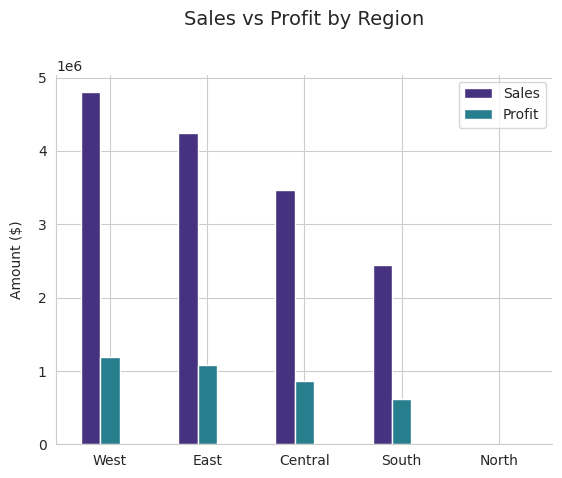

In [ ]:
q2 = duckdb.sql("""
    SELECT
    region,
    ROUND(SUM(sales_amount), 2) AS total_sales,
    ROUND(SUM(profit_amount), 2) AS total_profit,
    ROUND(SUM(profit_amount)/SUM(sales_amount)*100, 2) AS profit_margin_percentage
    FROM df
    GROUP BY region
    ORDER BY total_sales DESC
""").df()

plt.figure(figsize=(10,5))
q2.plot(x='region', kind='bar', stacked=False,
        color=[sns.color_palette(palette)[0], sns.color_palette(palette)[2]],
        width=0.6)
plt.title('Sales vs Profit by Region\n', fontsize=14, pad=20)
plt.xlabel('')
plt.ylabel('Amount ($)', labelpad=10)
plt.xticks(rotation=0)
sns.despine()
plt.legend(['Sales', 'Profit'])
plt.show()

## 3. What is the monthly trend of sales over time?


In [ ]:
import duckdb
duckdb.sql("""
    SELECT
    strftime(order_date, '%Y-%m') AS month,
    ROUND(SUM(sales_amount), 2) AS monthly_sales,
    COUNT(DISTINCT order_id) AS order_count
    FROM df
    GROUP BY month
    ORDER BY month;
    """)

┌─────────┬───────────────┬─────────────┐
│  month  │ monthly_sales │ order_count │
│ varchar │    double     │    int64    │
├─────────┼───────────────┼─────────────┤
│ 2015-01 │      122497.0 │          79 │
│ 2015-02 │       66030.0 │          46 │
│ 2015-03 │      247156.0 │         157 │
│ 2015-04 │      203258.0 │         135 │
│ 2015-05 │      164263.0 │         122 │
│ 2015-06 │      206064.0 │         135 │
│ 2015-07 │      220986.0 │         143 │
│ 2015-08 │      230161.0 │         153 │
│ 2015-09 │      382200.0 │         268 │
│ 2015-10 │      241726.0 │         159 │
│    ·    │          ·    │          ·  │
│    ·    │          ·    │          ·  │
│    ·    │          ·    │          ·  │
│ 2018-03 │      355704.0 │         238 │
│ 2018-04 │      310150.0 │         203 │
│ 2018-05 │      367411.0 │         242 │
│ 2018-06 │      354902.0 │         245 │
│ 2018-07 │      337092.0 │         226 │
│ 2018-08 │      331014.0 │         218 │
│ 2018-09 │      705680.0 │       

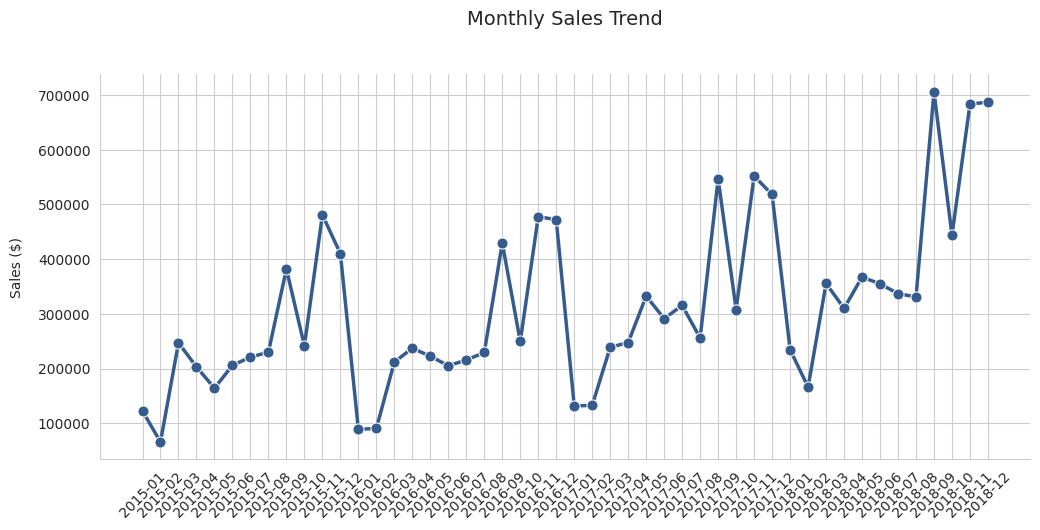

In [ ]:
q3 = duckdb.sql("""
    SELECT
    strftime(order_date, '%Y-%m') AS month,
    ROUND(SUM(sales_amount), 2) AS monthly_sales,
    COUNT(DISTINCT order_id) AS order_count
    FROM df
    GROUP BY month
    ORDER BY month
""").df()

plt.figure(figsize=(12,5))
sns.lineplot(x='month', y='monthly_sales', data=q3,
             marker='o', markersize=8,
             color=sns.color_palette(palette)[1],
             linewidth=2.5)
plt.title('Monthly Sales Trend\n', fontsize=14, pad=20)
plt.xlabel('')
plt.ylabel('Sales ($)', labelpad=10)
plt.xticks(rotation=45)
sns.despine()
plt.grid(True)
plt.show()

## 4. Which days of the week generate the most sales?

In [ ]:
import duckdb
duckdb.sql("""
    SELECT
    strftime(order_date, '%A') AS day_of_week,
    ROUND(SUM(sales_amount), 2) AS total_sales,
    COUNT(DISTINCT order_id) AS order_count
    FROM df
    GROUP BY day_of_week
    ORDER BY total_sales DESC;
    """)

┌─────────────┬─────────────┬─────────────┐
│ day_of_week │ total_sales │ order_count │
│   varchar   │   double    │    int64    │
├─────────────┼─────────────┼─────────────┤
│ Tuesday     │   2855751.0 │        1933 │
│ Saturday    │   2724409.0 │        1813 │
│ Sunday      │   2615647.0 │        1724 │
│ Monday      │   2428324.0 │        1628 │
│ Wednesday   │   1886849.0 │        1261 │
│ Friday      │   1638367.0 │        1091 │
│ Thursday    │    807635.0 │         544 │
└─────────────┴─────────────┴─────────────┘

<ipython-input-95-fe76ba7536f6>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



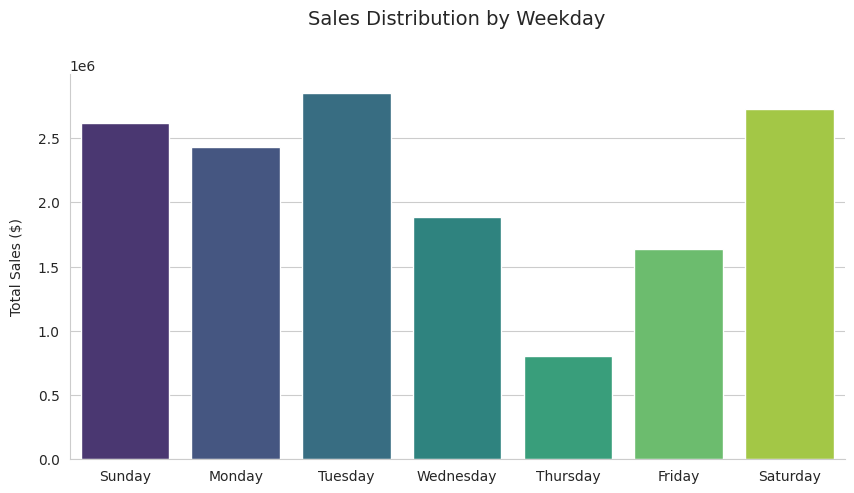

In [ ]:
q10 = duckdb.sql("""
    SELECT
    strftime(order_date, '%A') AS day_of_week,
    ROUND(SUM(sales_amount), 2) AS total_sales,
    COUNT(DISTINCT order_id) AS order_count
    FROM df
    GROUP BY day_of_week
    ORDER BY total_sales DESC
""").df()

weekday_order = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
plt.figure(figsize=(10,5))
sns.barplot(x='day_of_week', y='total_sales',
            data=q10, order=weekday_order,
            palette=palette)
plt.title('Sales Distribution by Weekday\n', fontsize=14, pad=20)
plt.xlabel('')
plt.ylabel('Total Sales ($)', labelpad=10)
sns.despine()
plt.show()

## 5. How do different discount levels affect product profitability?





In [ ]:
import duckdb
duckdb.sql("""
    SELECT
    CASE
        WHEN discount_amount = 0 THEN 'No Discount'
        WHEN discount_amount <= 0.1 THEN '0-10% Discount'
        WHEN discount_amount <= 0.2 THEN '10-20% Discount'
        ELSE '>20% Discount'
    END AS discount_range,
    AVG(profit_amount) AS avg_profit,
    COUNT(*) AS transaction_count
    FROM df
    GROUP BY discount_range
    ORDER BY discount_range;
    """)

┌─────────────────┬───────────────────┬───────────────────┐
│ discount_range  │    avg_profit     │ transaction_count │
│     varchar     │      double       │       int64       │
├─────────────────┼───────────────────┼───────────────────┤
│ 0-10% Discount  │ 361.8884153005465 │               366 │
│ 10-20% Discount │ 375.1450269106563 │              3716 │
│ >20% Discount   │ 375.6141948579166 │              5912 │
└─────────────────┴───────────────────┴───────────────────┘

<ipython-input-107-b4f5f553593d>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



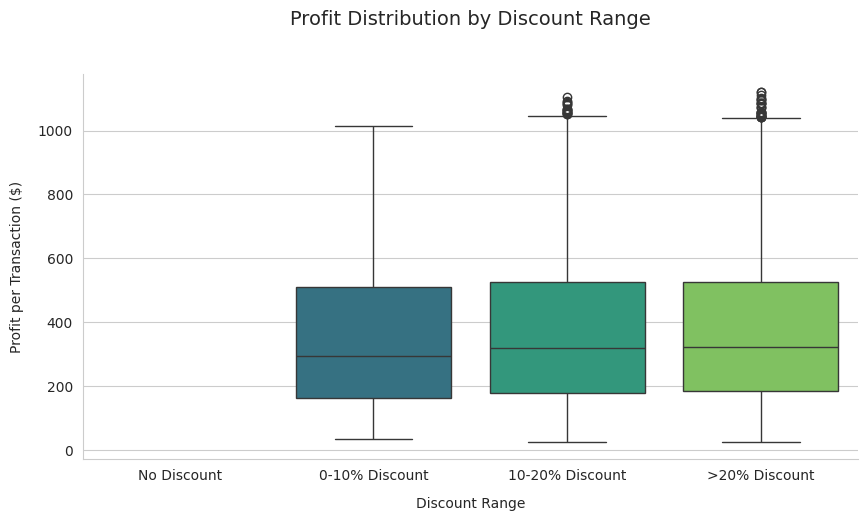

In [ ]:
q5 = duckdb.sql("""
    SELECT
    CASE
        WHEN discount_amount = 0 THEN 'No Discount'
        WHEN discount_amount <= 0.1 THEN '0-10% Discount'
        WHEN discount_amount <= 0.2 THEN '10-20% Discount'
        ELSE '>20% Discount'
    END AS discount_range,
    profit_amount  -- Use the raw profit amount for boxplot
    FROM df
""").df()

plt.figure(figsize=(10,5))
sns.boxplot(x='discount_range', y='profit_amount',
            data=q5,
            order=['No Discount', '0-10% Discount', '10-20% Discount', '>20% Discount'],
            palette=palette)
plt.title('Profit Distribution by Discount Range\n', fontsize=14, pad=20)
plt.xlabel('Discount Range', labelpad=10)
plt.ylabel('Profit per Transaction ($)', labelpad=10)
sns.despine()
plt.show()

## 6. Who are our top 10 customers by total spending?

In [ ]:
import duckdb
duckdb.sql("""
    SELECT
    customer_name,
    ROUND(SUM(sales_amount), 2) AS total_spent,
    COUNT(DISTINCT order_id) AS order_count
    FROM df
    GROUP BY customer_name
    ORDER BY total_spent DESC
    LIMIT 10;
    """)

┌───────────────┬─────────────┬─────────────┐
│ customer_name │ total_spent │ order_count │
│    varchar    │   double    │    int64    │
├───────────────┼─────────────┼─────────────┤
│ Krithika      │    334361.0 │         224 │
│ Amrish        │    333351.0 │         227 │
│ Verma         │    331665.0 │         218 │
│ Arutra        │    325720.0 │         218 │
│ Vidya         │    321798.0 │         215 │
│ Vinne         │    319565.0 │         203 │
│ Shah          │    318588.0 │         215 │
│ Suresh        │    315973.0 │         212 │
│ Adavan        │    315341.0 │         205 │
│ Surya         │    312645.0 │         209 │
├───────────────┴─────────────┴─────────────┤
│ 10 rows                         3 columns │
└───────────────────────────────────────────┘

In [ ]:
import plotly.express as px

q8 = duckdb.sql("""
    SELECT
    customer_name,
    ROUND(SUM(sales_amount), 2) AS total_spent,
    COUNT(DISTINCT order_id) AS order_count
    FROM df
    GROUP BY customer_name
    ORDER BY total_spent DESC
    LIMIT 10
""").df()

fig = px.scatter(
    q8,
    x="order_count",
    y="total_spent",
    size="total_spent",
    color="total_spent",
    hover_name="customer_name",  # Show name on hover
    size_max=30,  # Adjust bubble size
    title="Top Customers: Order Frequency vs Spending",
    labels={
        "order_count": "Number of Orders",
        "total_spent": "Total Spending ($)"
    },
    color_continuous_scale="viridis"  # Or your preferred palette
)

fig.update_layout(showlegend=False)  # Remove legend if needed
fig.show()

## 7. Which city have the highest profit margins?



In [ ]:
import duckdb
duckdb.sql("""
    SELECT
    city,
    ROUND(SUM(sales_amount), 2) AS total_sales,
    ROUND(SUM(profit_amount), 2) AS total_profit,
    ROUND(SUM(profit_amount)/SUM(sales_amount)*100, 2) AS profit_margin
    FROM df
    GROUP BY city
    ORDER BY profit_margin DESC;
    """)

┌────────────────┬─────────────┬──────────────┬───────────────┐
│      city      │ total_sales │ total_profit │ profit_margin │
│    varchar     │   double    │    double    │    double     │
├────────────────┼─────────────┼──────────────┼───────────────┤
│ Karur          │    642273.0 │    169305.94 │         26.36 │
│ Bodi           │    667177.0 │    173655.13 │         26.03 │
│ Perambalur     │    659738.0 │    171132.19 │         25.94 │
│ Vellore        │    676550.0 │    174073.01 │         25.73 │
│ Chennai        │    634963.0 │    160921.33 │         25.34 │
│ Krishnagiri    │    637273.0 │    160477.48 │         25.18 │
│ Dindigul       │    575631.0 │    144872.95 │         25.17 │
│ Trichy         │    541403.0 │    136059.94 │         25.13 │
│ Pudukottai     │    653179.0 │    164072.63 │         25.12 │
│ Ramanadhapuram │    634386.0 │    158951.03 │         25.06 │
│      ·         │        ·    │        ·     │           ·   │
│      ·         │        ·    │        

<ipython-input-124-4a4267b049aa>:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




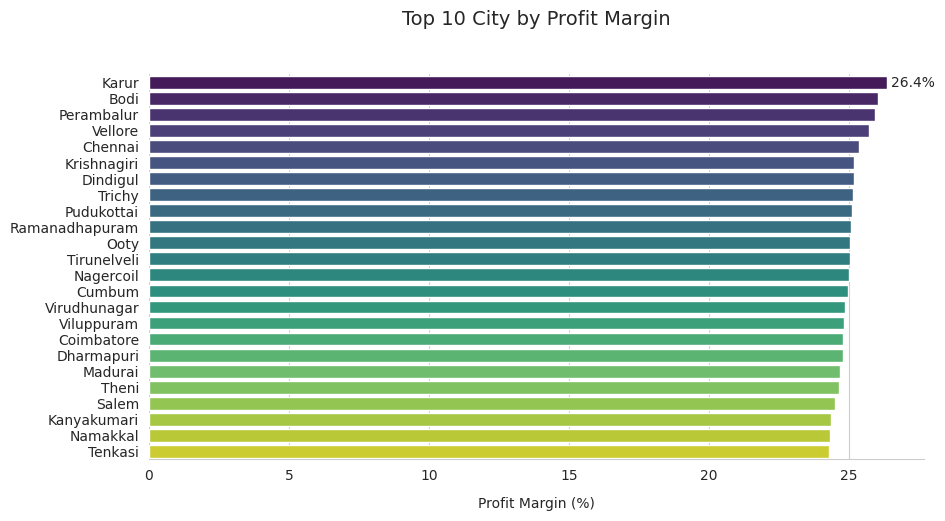

In [ ]:
q7 = duckdb.sql("""
    SELECT
    city,
    ROUND(SUM(sales_amount), 2) AS total_sales,
    ROUND(SUM(profit_amount), 2) AS total_profit,
    ROUND(SUM(profit_amount)/SUM(sales_amount)*100, 2) AS profit_margin
    FROM df
    GROUP BY city
    ORDER BY profit_margin DESC
""").df()

plt.figure(figsize=(10,5))
ax = sns.barplot(y='city', x='profit_margin',
                 data=q7, palette=palette)
plt.title('Top 10 City by Profit Margin\n', fontsize=14, pad=20)
plt.xlabel('Profit Margin (%)', labelpad=10)
plt.ylabel('')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
sns.despine(left=True)
plt.show()
# Bubble chart with city names
fig = px.scatter(q7, x='total_sales', y='profit_margin',
                 size='total_sales', color='profit_margin',
                 hover_name='city', log_x=True,
                 title='Profit Margins vs Sales by City')
fig.show()

## 8. Which customers make repeat purchases and what is their lifetime value?


In [ ]:
import duckdb
duckdb.sql("""
    SELECT
    customer_name,
    MIN(order_date) AS first_order_date,
    MAX(order_date) AS last_order_date,
    COUNT(DISTINCT order_id) AS order_count,
    ROUND(SUM(sales_amount), 2) AS total_spent
    FROM df
    GROUP BY customer_name
    HAVING COUNT(DISTINCT order_id) > 1
    ORDER BY order_count DESC
    LIMIT 10;
    """)

┌───────────────┬─────────────────────┬─────────────────────┬─────────────┬─────────────┐
│ customer_name │  first_order_date   │   last_order_date   │ order_count │ total_spent │
│    varchar    │    timestamp_ns     │    timestamp_ns     │    int64    │   double    │
├───────────────┼─────────────────────┼─────────────────────┼─────────────┼─────────────┤
│ Amrish        │ 2015-01-13 00:00:00 │ 2018-12-27 00:00:00 │         227 │    333351.0 │
│ Krithika      │ 2015-01-13 00:00:00 │ 2018-12-28 00:00:00 │         224 │    334361.0 │
│ Verma         │ 2015-01-05 00:00:00 │ 2018-12-28 00:00:00 │         218 │    331665.0 │
│ Arutra        │ 2015-01-10 00:00:00 │ 2018-12-26 00:00:00 │         218 │    325720.0 │
│ Vidya         │ 2015-01-13 00:00:00 │ 2018-12-28 00:00:00 │         215 │    321798.0 │
│ Shah          │ 2015-03-03 00:00:00 │ 2018-12-25 00:00:00 │         215 │    318588.0 │
│ Suresh        │ 2015-01-20 00:00:00 │ 2018-12-25 00:00:00 │         212 │    315973.0 │
│ Surya   

In [ ]:
q8 = duckdb.sql("""
    SELECT
    customer_name,
    MIN(order_date) AS first_order_date,
    MAX(order_date) AS last_order_date,
    COUNT(DISTINCT order_id) AS order_count,
    ROUND(SUM(sales_amount), 2) AS total_spent
    FROM df
    GROUP BY customer_name
    HAVING COUNT(DISTINCT order_id) > 1
    ORDER BY order_count DESC
    LIMIT 10;
""").df()

import plotly.express as px

fig = px.scatter(
    q8,
    x='order_count',
    y='total_spent',
    size='total_spent',
    color='total_spent',
    hover_name='customer_name',
    title='Repeat Customers: Order Frequency vs Spending'
)
fig.update_layout(
    xaxis_title='Number of Orders',
    yaxis_title='Total Spending ($)'
)
fig.show()

## 9. How do different subcategories perform within each category?

In [ ]:
import duckdb
duckdb.sql("""
    SELECT
    subcategory,
    category,
    ROUND(SUM(sales_amount), 2) AS total_sales,
    ROUND(SUM(profit_amount), 2) AS total_profit,
    ROUND(AVG(discount_amount)*100, 2) AS avg_discount_percentage
    FROM df
    GROUP BY subcategory, category
    ORDER BY total_profit DESC;
    """)

┌────────────────────┬───────────────────┬─────────────┬──────────────┬─────────────────────────┐
│    subcategory     │     category      │ total_sales │ total_profit │ avg_discount_percentage │
│      varchar       │      varchar      │   double    │    double    │         double          │
├────────────────────┼───────────────────┼─────────────┼──────────────┼─────────────────────────┤
│ Health Drinks      │ Beverages         │   1051439.0 │    267469.79 │                   23.16 │
│ Soft Drinks        │ Beverages         │   1033874.0 │    258135.97 │                    22.9 │
│ Noodles            │ Snacks            │    735435.0 │    193685.81 │                   22.19 │
│ Breads & Buns      │ Bakery            │    742586.0 │    190764.98 │                   22.65 │
│ Cookies            │ Snacks            │    768213.0 │     190643.7 │                   21.87 │
│ Chocolates         │ Snacks            │    733898.0 │    183849.34 │                   22.57 │
│ Biscuits          

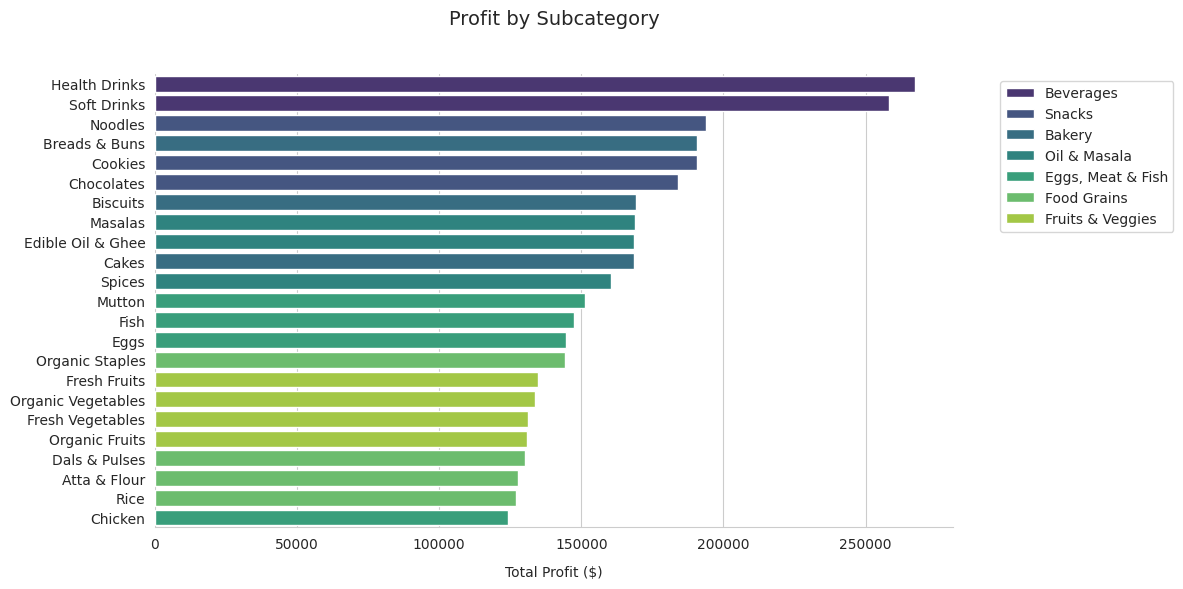

In [ ]:
q9 = duckdb.sql("""
    SELECT
    subcategory,
    category,
    ROUND(SUM(sales_amount), 2) AS total_sales,
    ROUND(SUM(profit_amount), 2) AS total_profit,
    ROUND(AVG(discount_amount)*100, 2) AS avg_discount_percentage
    FROM df
    GROUP BY subcategory, category
    ORDER BY total_profit DESC;
""").df()

plt.figure(figsize=(12,6))
sns.barplot(y='subcategory', x='total_profit',
            hue='category', data=q9,
            dodge=False, palette=palette)
plt.title('Profit by Subcategory\n', fontsize=14, pad=20)
plt.xlabel('Total Profit ($)', labelpad=10)
plt.ylabel('')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(left=True)
plt.tight_layout()
plt.show()

## 10. Customer Segmentation

In [ ]:
import duckdb
duckdb.sql("""
    SELECT
    customer_name,
    ROUND(SUM(sales_amount), 2) AS total_sales_amount
    FROM df
    GROUP BY customer_name
    ORDER BY total_sales_amount DESC;
    """)

┌───────────────┬────────────────────┐
│ customer_name │ total_sales_amount │
│    varchar    │       double       │
├───────────────┼────────────────────┤
│ Krithika      │           334361.0 │
│ Amrish        │           333351.0 │
│ Verma         │           331665.0 │
│ Arutra        │           325720.0 │
│ Vidya         │           321798.0 │
│ Vinne         │           319565.0 │
│ Shah          │           318588.0 │
│ Suresh        │           315973.0 │
│ Adavan        │           315341.0 │
│ Surya         │           312645.0 │
│   ·           │               ·    │
│   ·           │               ·    │
│   ·           │               ·    │
│ Vince         │           284536.0 │
│ Rumaiza       │           284534.0 │
│ Anu           │           283735.0 │
│ Esther        │           283656.0 │
│ Ganesh        │           278349.0 │
│ Sudha         │           273493.0 │
│ Yadav         │           273162.0 │
│ Jackson       │           271793.0 │
│ Kumar         │        

<ipython-input-140-db50832b5e88>:11: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



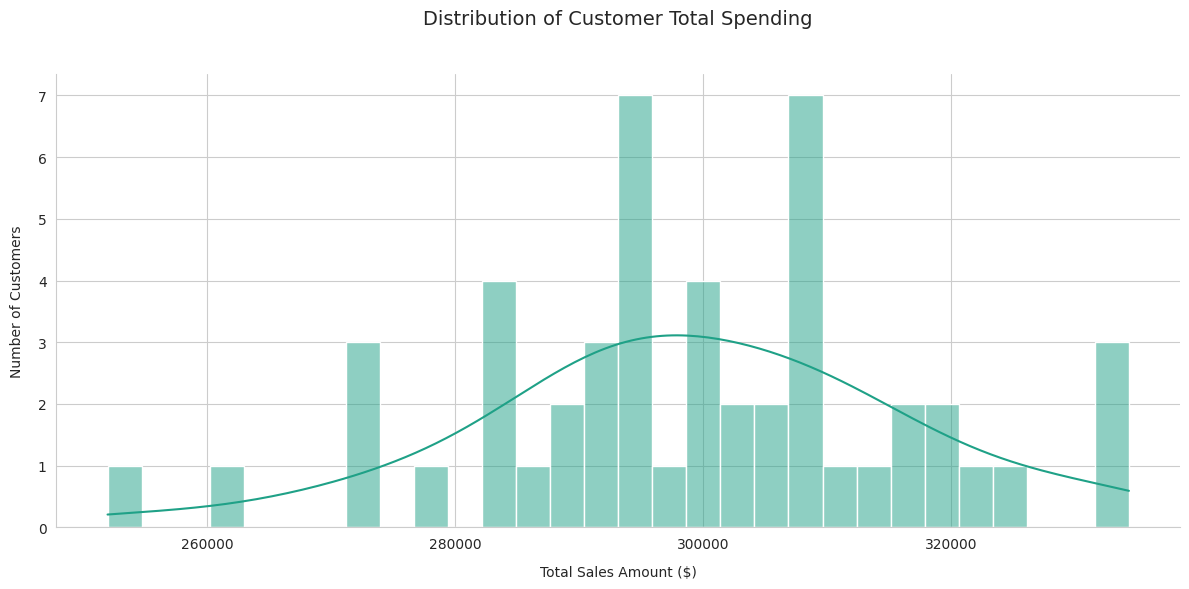

In [ ]:
q10 = duckdb.sql("""
    SELECT
    customer_name,
    ROUND(SUM(sales_amount), 2) AS total_sales_amount
    FROM df
    GROUP BY customer_name
    ORDER BY total_sales_amount DESC;
""").df()

plt.figure(figsize=(12,6))
sns.histplot(x='total_sales_amount', data=q10,
             bins=30, kde=True, palette=palette,
             color=sns.color_palette(palette)[3])
plt.title('Distribution of Customer Total Spending\n', fontsize=14, pad=20)
plt.xlabel('Total Sales Amount ($)', labelpad=10)
plt.ylabel('Number of Customers', labelpad=10)
sns.despine()
plt.tight_layout()
plt.show()

## Combines classic RFM (Recency, Frequency, Monetary) with category preferences for actionable segments.
R (Recency): The time interval since the most recent purchase, which refers to how long it has been since a customer last made a purchase. This measures customer engagement—the smaller the R value, the more engaged the customer.

F (Frequency): The purchase frequency within the analysis period, which refers to how many times a customer has made purchases during the observed timeframe. This measures customer loyalty—the higher the F value, the more loyal the customer.

M (Monetary): The total spending amount within the analysis period, which refers to how much money a customer has spent during the observed timeframe. This measures customer value—the higher the amount, the more valuable the customer.

Feature Engineering

In [ ]:
# Import computational libraries and dataset
import pandas as pd
from sklearn.cluster import KMeans

# Since each order has multiple rows, first group by customer_name, order_date, order_id to sum the sales_amount
df_uniqueorder = df.groupby(["customer_name", "order_date", "order_id"]).agg({'sales_amount':'sum'}).reset_index()
df_uniqueorder.head(5)

# Create RFM table
df_rfm = df_uniqueorder.groupby("customer_name").agg({'order_date':'max', 'order_id':'count', 'sales_amount':'sum'})
df_rfm = df_rfm.rename(columns={'order_date':'Recentdate', 'order_id':'F', 'sales_amount':'M'})

lastday = df['order_date'].max()
# Calculate R value (days since last purchase relative to analysis date)
df_rfm["R"] = pd.to_datetime(lastday) - df_rfm["Recentdate"]
df_rfm["R"] = df_rfm["R"].astype('str').str.split(" ", expand=True)[0]
df_rfm["R"] = df_rfm["R"].astype("int")
df_rfm.drop(columns='Recentdate', inplace=True)

# Merge region information (assuming 'region' as the area)
region_info = df[["customer_name", "region"]].groupby("customer_name").agg("max").reset_index()
RFM = df_rfm.merge(region_info, on="customer_name", how="left")

# Make a copy of the original RFM data
RFM_Average = RFM.copy()

# Compare each metric against the overall mean to determine high/low
RFM_Average["IFR"] = RFM_Average["R"].apply(lambda x: "High" if x > RFM_Average["R"].mean() else "Low")
RFM_Average["IFF"] = RFM_Average["F"].apply(lambda x: "High" if x > RFM_Average["F"].mean() else "Low")
RFM_Average["IFM"] = RFM_Average["M"].apply(lambda x: "High" if x > RFM_Average["M"].mean() else "Low")
RFM_Average.head(5)

# Define customer classification function
def iflabel(x):
    if x == "HighHighHigh":
        return "High-Value Customer"
    elif x == "HighLowHigh":
        return "High-Potential Customer"
    elif x == "HighHighLow":
        return "General-Value Customer"
    elif x == "HighLowLow":
        return "General-Potential Customer"
    elif x == "LowHighHigh":
        return "High-Retention Customer"
    elif x == "LowLowHigh":
        return "High-Churn-Risk Customer"
    elif x == "LowHighLow":
        return "General-Retention Customer"
    elif x == "LowLowLow":
        return "General-Churn-Risk Customer"

# Combine the three metrics to create a temporary column 'temp'
RFM_Average["temp"] = RFM_Average["IFR"] + RFM_Average["IFF"] + RFM_Average["IFM"]  # Fixed duplicate IFR issue in original code

# Evaluate the composite metric
RFM_Average["label"] = RFM_Average["temp"].apply(lambda x: iflabel(x))

In [ ]:
RFM_Average.head()

,customer_name,F,M,R,region,IFR,IFF,IFM,temp,label
0,Adavan,205,315341,7,West,High,High,High,HighHighHigh,High-Value Customer
1,Aditi,187,299674,1,West,Low,Low,High,LowLowHigh,High-Churn-Risk Customer
2,Akash,196,307488,2,West,Low,Low,High,LowLowHigh,High-Churn-Risk Customer
3,Alan,198,294397,6,West,High,Low,Low,HighLowLow,General-Potential Customer
4,Amrish,227,333351,3,West,Low,High,High,LowHighHigh,High-Retention Customer


In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Basic RFM Scatter Plot (3D)
fig = px.scatter_3d(
    RFM_Average,
    x='R',
    y='F',
    z='M',
    color='label',
    hover_name='customer_name',
    title='RFM Analysis Dashboard',
    labels={'R': 'Recency', 'F': 'Frequency', 'M': 'Monetary Value'}
)
fig.update_layout(margin=dict(l=0, r=0, b=0, t=30))
fig.show()

# 2. Advanced Dashboard with Subplots
fig = make_subplots(
    rows=1, cols=3,
    specs=[

        [{'type': 'pie'}, {'type': 'bar'},{'type': 'scatter'}]
    ],
    subplot_titles=(

        'Average Values by Segment',
        'Customer Distribution',
        'Recency vs Monetary'
    )
)

# Bar Chart (Average Metrics)
segment_means = RFM_Average.groupby('label')[['R', 'F', 'M']].mean()
for i, col in enumerate(['R', 'F', 'M']):
    fig.add_trace(
        go.Bar(
            x=segment_means.index,
            y=segment_means[col],
            name=col,
            textposition='auto'
        ),
        row=1, col=2
)

# Pie Chart (Distribution)
label_counts = RFM_Average['label'].value_counts()
fig.add_trace(
    go.Pie(
        labels=label_counts.index,
        values=label_counts.values,
        hole=0.3,
        showlegend=False
    ),
    row=1, col=1
)

# Scatter Plot (R vs M)
fig.add_trace(
    go.Scatter(
        x=RFM_Average['R'],
        y=RFM_Average['M'],
        mode='markers',
        marker=dict(
            color=RFM_Average['F'],
            colorscale='thermal',
            showscale=True,
            size=RFM_Average['F']*0.
        ),
        text=RFM_Average['label'],
        hovertext=RFM_Average['customer_name']
    ),
    row=1, col=3
)

# Update layout
fig.update_layout(
    title_text='3D Customer Segment',
    height=400,
    showlegend=True,
    template='plotly_white'
)

fig.show()

# Recommendations
**Focus on High-Value Customers:** Offer personalized promotions to customers like Amrish and Krithika to maintain loyalty.

**Re-engage Churn-Risk Customers:** Target customers like Hafiz and Anu with reactivation campaigns (e.g., discounts, reminders).

**Promote Profitable Categories:** Increase marketing for Snacks and Eggs, Meat & Fish to boost sales in high-profit categories.

**Monitor Retention Customers:** Provide loyalty programs for frequent buyers (e.g., Surya, Verma) to prevent churn.